# Notebook 2: Multi-Agent Energy Management Environment

This notebook builds the PettingZoo environment used for the
Multi-Agent Reinforcement Learning experiment.

The microgrid contains four cooperative agents:

1. Building A - flexible electricity consumption
2. Building B - flexible electricity consumption
3. Battery - local energy storage
4. Grid Interface - electricity import/export

The environment models three competing objectives:

- Economic efficiency
- Carbon emission reduction
- Grid stability

Function/library roles:

numpy — numerical calculations and arrays.
pandas — loading and manipulating the BDG2 data.
matplotlib.pyplot — visualizing environment behaviour.
Path — handles Windows/Linux file paths safely.
spaces — defines valid observations and actions.
ParallelEnv — PettingZoo base class where all agents act simultaneously.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from gymnasium import spaces
from pettingzoo import ParallelEnv

In [3]:
#Loading the processes BDG2 data:

PROJ_DIR = Path(r"C:\Users\prish\building-data-genome-project-2")
PROCESSED_DIR = PROJ_DIR / "data" / "processed"
DATA_FILE = PROCESSED_DIR / "bdg2_clean.csv"

df = pd.read_csv(
    DATA_FILE,
    parse_dates=["timestamp"],
    index_col="timestamp"
)

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

                     building_a  building_b  solar
timestamp                                         
2016-01-01 00:00:00     56.6201     65.2500   0.02
2016-01-01 01:00:00     59.8800     61.5000   0.01
2016-01-01 02:00:00     63.5001     63.7500   0.02
2016-01-01 03:00:00     59.7501     65.5001   0.02
2016-01-01 04:00:00     56.2501     67.5001   0.00

Shape: (8575, 3)

Columns: ['building_a', 'building_b', 'solar']


In [4]:
#Basic validation:

print("Missing values:")
print(df.isna().sum())

print("\nMinimum values:")
print(df.min())

print("\nMaximum values:")
print(df.max())

print("\nTime range:")
print(df.index.min(), "→", df.index.max())

Missing values:
building_a    0
building_b    0
solar         0
dtype: int64

Minimum values:
building_a    18.5
building_b     9.0
solar          0.0
dtype: float64

Maximum values:
building_a    84.0001
building_b    94.0000
solar         16.1400
dtype: float64

Time range:
2016-01-01 00:00:00 → 2016-12-23 06:00:00


In [5]:
#Normalizing the energy variables

energy_columns=["building_a","building_b","solar"]

for column in energy_columns:
    max_value=df[column].max()
    if max_value>0:
        df[column]/=max_value
        
print(df[energy_columns].describe())

        building_a   building_b        solar
count  8575.000000  8575.000000  8575.000000
mean      0.508046     0.565472     0.213844
std       0.100270     0.088379     0.323527
min       0.220238     0.095745     0.000000
25%       0.435952     0.500000     0.000620
50%       0.501428     0.569149     0.001859
75%       0.574404     0.630320     0.373606
max       1.000000     1.000000     1.000000


Defining the electricity price

In [6]:
def get_electricity_price(hour):
    """
    Return the time-of-use electricity price for an hour.
    """
    if 0<=hour<6:
        return 0.08
    elif 6<=hour<17:
        return 0.12
    else:
        return 0.20

Defining carbon intensity.
High solar → lower carbon intensity.
Low solar → higher carbon intensity.

In [7]:
def get_carbon_intensity(solar):
    """
    Estimate normalized grid carbon intensity from solar availability.
    Higher solar availability corresponds to lower carbon intensity.
    """
    carbon=1.0-solar
    return np.clip(carbon,0.2,1.0) 

Defining agents : 4 Agents (decision-makers)
- Building A
- Building B
- Battery
- Grid
Solar -> Environmental process (not an agent)

In [8]:
AGENTS = [
    "building_a",
    "building_b",
    "battery",
    "grid"
]

Environment Class

Tracks: current timestep, active agent list, battery capacity/state-of-charge, charge/discharge limits and efficiencies, and current grid import/export values

In [9]:
class MicrogridEnv(ParallelEnv):
    metadata = {"name": "bdg2_microgrid_v0"}
 
    # Grid agent's action -> fraction of unmet demand actually imported.
    GRID_IMPORT_FRACTIONS = {
        0: 0.5,   # idle    -> partial import (moderate curtailment)
        1: 1.0,   # import  -> full import (cover all unmet demand)
        2: 0.25,  # curtail -> deep curtailment (save cost/carbon, hurt stability)
    }
 
    def __init__(self, data, episode_length=24,
                 cost_norm=0.4, emissions_norm=2.0, deviation_norm=None):

        self.data = data.reset_index(drop=False)
        self.episode_length = episode_length
        self.possible_agents = AGENTS.copy()
        self.agents = AGENTS.copy()
        self.episode_start = 0
 
        # Reward normalization constants 
        self.cost_norm = 0.1454,
        self.emissions_norm = 1.0595,
        self.deviation_norm = deviation_norm
 
        # Battery Parameters
        self.battery_capacity = 1.0
        self.battery_soc = 0.5
        self.max_charge = 0.25
        self.max_discharge = 0.25
        self.charge_efficiency = 0.90
        self.discharge_efficiency = 0.90
 
        # Current system values
        self.grid_import = 0.0
        self.grid_export = 0.0
 
        # Action Spaces
        self.action_spaces = {
            # 0 = reduce flexible demand
            # 1 = normal demand
            # 2 = increase flexible demand
            "building_a": spaces.Discrete(3),
            "building_b": spaces.Discrete(3),
 
            # 0 = idle
            # 1 = charge
            # 2 = discharge
            "battery": spaces.Discrete(3),
 
            # See GRID_IMPORT_FRACTIONS above:
            # 0 = idle (50% import), 1 = import (100%), 2 = curtail (25%)
            "grid": spaces.Discrete(3)
        }
 
        # Operator Modes
        self.operator_modes = {
            "economy": 0,
            "sustainability": 1,
            "reliability": 2
        }
 
        self.operator_mode = 0
 
        # Current reward weights
        self.weights = np.array(
            [1 / 3, 1 / 3, 1 / 3],
            dtype=np.float32
        )
 
        LOCAL_OBS_SIZE = 11
 
        self.observation_spaces = {
            agent: spaces.Box(
                low=np.zeros(LOCAL_OBS_SIZE, dtype=np.float32),
                high=np.ones(LOCAL_OBS_SIZE, dtype=np.float32),
                dtype=np.float32
            )
            for agent in AGENTS
        }
 
        GLOBAL_STATE_SIZE = 13
 
        self.global_state_space = spaces.Box(
            low=np.zeros(GLOBAL_STATE_SIZE, dtype=np.float32),
            high=np.ones(GLOBAL_STATE_SIZE, dtype=np.float32),
            dtype=np.float32
        )
 
    def action_space(self, agent):
        return self.action_spaces[agent]
 
    def observation_space(self, agent):
        return self.observation_spaces[agent]
 
    # Building Flexibility
 
    def _building_demand(self, base_demand, action):
        if action == 0:
            return base_demand * 0.90
        elif action == 1:
            return base_demand
        else:
            return base_demand * 1.10
 
    # Battery Dynamics
 
    def _battery_energy(self, action, excess_solar, remaining_demand):
        charge = 0.0
        discharge = 0.0
 
        if action == 1:
            charge = min(
                self.max_charge, excess_solar,
                (self.battery_capacity - self.battery_soc) / self.charge_efficiency
            )
            self.battery_soc += charge * self.charge_efficiency
        elif action == 2:
            discharge = min(
                self.max_discharge,
                self.battery_soc * self.discharge_efficiency,
                remaining_demand
            )
            self.battery_soc -= discharge / self.discharge_efficiency
 
        self.battery_soc = np.clip(self.battery_soc, 0.0, self.battery_capacity)
 
        return charge, discharge
 
    def _get_observations(self):
        row = self.data.iloc[self.current_step]
        hour = pd.Timestamp(row["timestamp"]).hour
        price = get_electricity_price(hour)
        carbon = get_carbon_intensity(row["solar"])
        grid_load = min(self.grid_import, 1.0)
 
        mode = np.zeros(3, dtype=np.float32)
        mode[self.operator_mode] = 1.0
 
        common_state = np.array([
            grid_load,
            price / 0.20,
            row["solar"],
            carbon,
            self.weights[0],
            self.weights[1],
            self.weights[2],
            mode[0],
            mode[1],
            mode[2]
        ], dtype=np.float32)
 
        observations = {
            "building_a": np.concatenate([[row["building_a"]], common_state]),
            "building_b": np.concatenate([[row["building_b"]], common_state]),
            "battery": np.concatenate([[self.battery_soc], common_state]),
            "grid": np.concatenate([[grid_load], common_state])
        }
        return observations
 
    def get_global_state(self):
        row = self.data.iloc[self.current_step]
        hour = pd.Timestamp(row["timestamp"]).hour
        price = get_electricity_price(hour)
        carbon = get_carbon_intensity(row["solar"])
 
        mode = np.zeros(3, dtype=np.float32)
        mode[self.operator_mode] = 1.0
 
        global_state = np.array([
            row["building_a"],
            row["building_b"],
            self.battery_soc,
            row["solar"],
            min(self.grid_import, 1.0),
            price / 0.20,
            carbon,
            self.weights[0],
            self.weights[1],
            self.weights[2],
            mode[0],
            mode[1],
            mode[2]
        ], dtype=np.float32)
 
        return global_state
 
    def reset(self, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
 
        max_start = len(self.data) - self.episode_length
        self.episode_start = np.random.randint(0, max_start + 1)
        self.current_step = self.episode_start
 
        self.agents = self.possible_agents.copy()
        self.battery_soc = 0.5
        self.grid_import = 0.0
        self.grid_export = 0.0
        self.weights = np.array([1 / 3, 1 / 3, 1 / 3], dtype=np.float32)
        self.operator_mode = 0
 
        observations = self._get_observations()
        return observations, {}
 
    def _cost_reward(self, grid_import, price):
        raw_cost = grid_import * price
        normalized_cost = raw_cost / self.cost_norm
        return -np.clip(normalized_cost, 0.0, 1.0)
 
    def _carbon_reward(self, grid_import, carbon):
        raw_emissions = grid_import * carbon
        normalized_emissions = raw_emissions / self.emissions_norm
        return -np.clip(normalized_emissions, 0.0, 1.0)
 
    def _get_target_grid_load(self):
        start = self.episode_start
        end = min(self.episode_start + self.episode_length, len(self.data))
 
        demand = (
            self.data.iloc[start:end]["building_a"]
            + self.data.iloc[start:end]["building_b"]
        )
        return demand.mean()
 
    def _stability_reward(self, grid_load, target_grid_load):
        deviation = abs(grid_load - target_grid_load)
        denom = self.deviation_norm if self.deviation_norm is not None else max(target_grid_load, 1e-6)
        normalized_deviation = deviation / denom
        return -np.clip(normalized_deviation, 0.0, 1.0)
 
    def _calculate_reward(self, grid_import, price, carbon, grid_load, target_grid_load):
        r_cost = self._cost_reward(grid_import, price)
        r_carbon = self._carbon_reward(grid_import, carbon)
        r_stability = self._stability_reward(grid_load, target_grid_load)
 
        reward = (
            self.weights[0] * r_cost
            + self.weights[1] * r_carbon
            + self.weights[2] * r_stability
        )
 
        components = {
            "cost_reward": r_cost,
            "carbon_reward": r_carbon,
            "stability_reward": r_stability,
            "total_reward": reward
        }
        return reward, components
 
    def step(self, actions):
        row = self.data.iloc[self.current_step]
        hour = pd.Timestamp(row["timestamp"]).hour
        price = get_electricity_price(hour)
        carbon = get_carbon_intensity(row["solar"])
 
        # 1. Building actions
        demand_a = self._building_demand(row["building_a"], actions["building_a"])
        demand_b = self._building_demand(row["building_b"], actions["building_b"])
        total_demand = demand_a + demand_b
 
        # 2. Solar generation
        solar = row["solar"]
        solar_to_buildings = min(solar, total_demand)
        remaining_demand = total_demand - solar_to_buildings
        excess_solar = solar - solar_to_buildings
 
        # 3. Battery action
        battery_charge, battery_discharge = self._battery_energy(
            actions["battery"], excess_solar, remaining_demand
        )
        excess_solar -= battery_charge
        remaining_demand -= battery_discharge
 
        # 4. Grid interaction — grid agent controls WHAT FRACTION of unmet
        #    demand gets imported (graduated curtailment lever), rather than
        #    an on/off gate. Export always happens automatically when there's
        #    excess solar, since grid_export never affects reward.
        grid_action = actions["grid"]
        import_fraction = self.GRID_IMPORT_FRACTIONS[grid_action]
 
        grid_import = remaining_demand * import_fraction if remaining_demand > 0 else 0.0
        grid_export = excess_solar if excess_solar > 0 else 0.0
 
        # 5. Aggregate grid load
        self.grid_import = grid_import
        self.grid_export = grid_export
        grid_load = grid_import
 
        # 6. Target flat grid load
        target_grid_load = self._get_target_grid_load()
 
        # 7. Multi-objective reward
        reward, reward_components = self._calculate_reward(
            grid_import, price, carbon, grid_load, target_grid_load
        )
 
        # 8. Advance environment
        self.current_step += 1
        terminated = (self.current_step - self.episode_start) >= self.episode_length
        if terminated:
            self.agents = []
            observations = {}
        else:
            observations = self._get_observations()
 
        # 9. Cooperative rewards
        rewards = {agent: reward for agent in self.possible_agents}
        terminations = {agent: terminated for agent in self.possible_agents}
        truncations = {agent: False for agent in self.possible_agents}
 
        # 10. Diagnostic information
        infos = {
            agent: {
                "building_a_demand": demand_a,
                "building_b_demand": demand_b,
                "total_demand": total_demand,
                "solar": solar,
                "battery_soc": self.battery_soc,
                "battery_charge": battery_charge,
                "battery_discharge": battery_discharge,
                "grid_import": grid_import,
                "grid_export": grid_export,
                "grid_load": grid_load,
                "target_grid_load": target_grid_load,
                "price": price,
                "carbon_intensity": carbon,
                **reward_components
            }
            for agent in self.possible_agents
        }
 
        return observations, rewards, terminations, truncations, infos
 
 
def calibrate_reward_norms(env_factory, n_episodes=200):
    """
    Run random-action rollouts and report percentiles of raw_cost,
    raw_emissions, and grid-load deviation, so cost_norm / emissions_norm /
    deviation_norm can be set from real data instead of guessed constants.
 
    IMPORTANT: raw_cost and raw_emissions are computed from grid_import
    (what the reward function actually uses), not total_demand — re-run
    this any time the grid-interaction logic changes, since that changes
    what grid_import equals for a given state/action.
 
    Usage:
        stats = calibrate_reward_norms(lambda: MicrogridEnv(data=df, episode_length=24))
        env = MicrogridEnv(data=df, episode_length=24,
                            cost_norm=stats["raw_cost"]["p90"],
                            emissions_norm=stats["raw_emissions"]["p90"])
    """
    raw_costs, raw_emissions, deviations = [], [], []
 
    for _ in range(n_episodes):
        env = env_factory()
        obs, _ = env.reset()
        done = False
        while not done:
            actions = {a: env.action_space(a).sample() for a in env.possible_agents}
            obs, rewards, term, trunc, infos = env.step(actions)
            info = infos[env.possible_agents[0]]
            raw_costs.append(info["grid_import"] * info["price"])
            raw_emissions.append(info["grid_import"] * info["carbon_intensity"])
            deviations.append(abs(info["grid_load"] - info["target_grid_load"]))
            done = term[env.possible_agents[0]] or trunc[env.possible_agents[0]]
 
    def summarize(values):
        arr = np.array(values)
        return {
            "p50": float(np.percentile(arr, 50)),
            "p90": float(np.percentile(arr, 90)),
            "p99": float(np.percentile(arr, 99)),
            "max": float(arr.max()),
        }
 
    stats = {
        "raw_cost": summarize(raw_costs),
        "raw_emissions": summarize(raw_emissions),
        "deviation": summarize(deviations),
    }
 
    for name, s in stats.items():
        print(f"{name}: p50={s['p50']:.4f}  p90={s['p90']:.4f}  p99={s['p99']:.4f}  max={s['max']:.4f}")
 
    return stats

Action Spaces

spaces.Discrete(3) — defines a 3-valued discrete action space per agent.

Meaning: buildings choose to reduce/keep/increase consumption; the battery chooses idle/charge/discharge; the grid interface choose idle/import/export.

Operator Modes

Encodes the report's three human priority modes as integers so the mode can be fed into the neural network observation (via one-hot encoding later).

Reward Weights

w1, w2, w3 correspond to cost, carbon, and stability weights. Initialized equally; the four experimental configurations (A/B/C/D) will control these later in Notebook 3.

Function used

spaces.Box(low, high, dtype) — defines a continuous, bounded 11-dimensional observation vector for each agent.

Observation layout (11 values)

Local variable (own demand / SOC / grid load)
Aggregate grid load
Electricity price
Solar
Carbon intensity 6–8. Reward weights w1, w2, w3 9–11. One-hot operator mode (economy / sustainability / reliability)

Each agent only sees its own local variable plus this shared context — not the full system state.


Calculate local observations:
Each agent gets its own local value (demand / SOC / grid load) plus the same shared context — this is the decentralized-execution observation design.

Global State
Builds the full 13-value system state used only by the centralized critic during training (actor → local observation → action; critic → global state → value estimate). This is the centralized-training/decentralized-execution (CTDE) architecture.

Reset:

np.random.seed() — makes the episode reproducible.

Resets all mutable state (step counter, agents, battery SOC, grid flows, weights, mode) at the start of each episode.

Calls _get_observations() to return the first set of observations.

Cost Reward:

Multiplication — computes raw electricity expenditure (import × price).
np.clip() — bounds the normalized cost to [0, 1] before negating it.

Higher grid import → higher cost → more negative reward. max_cost is an implementation-chosen normalization constant, not specified by the report.

Flat target grid load: Used to check deviation with actual grid load

.iloc[start:end] — slices the remaining rows of the current episode.

.mean() — computes the average combined building demand, used as the flat target grid-load profile for the stability reward.

Stability reward:

Functions used

abs() — absolute deviation of actual grid load from the flat target.
max(target_grid_load, 1e-6) — avoids division by zero.
np.clip() — bounds the normalized deviation before negating it.

Larger deviation from the flat target → worse (more negative) stability reward.

AMORM: Combined Reward Function

In [10]:
def _get_target_grid_load(self):
    start = self.current_step
    end = min(start + self.episode_length, len(self.data))

    demand = (
        self.data.iloc[start:end]["building_a"]
        + self.data.iloc[start:end]["building_b"]
    )
    return demand.mean()

def _stability_reward(self, grid_load, target_grid_load):
    deviation = abs(grid_load - target_grid_load)
    normalized_deviation = deviation / max(target_grid_load, 1e-6)
    return -np.clip(normalized_deviation, 0.0, 1.0)

def _calculate_reward(self, grid_import, price, carbon, grid_load, target_grid_load):
    r_cost = self._cost_reward(grid_import, price)
    r_carbon = self._carbon_reward(grid_import, carbon)
    r_stability = self._stability_reward(grid_load, target_grid_load)

    reward = (
        self.weights[0] * r_cost
        + self.weights[1] * r_carbon
        + self.weights[2] * r_stability
    )

    components = {
        "cost_reward": r_cost,
        "carbon_reward": r_carbon,
        "stability_reward": r_stability,
        "total_reward": reward
    }
    return reward, components

Main environment setup:

1. Compute flexible building demand from actions.
2. Route solar generation to buildings first.
3. Route any excess/insufficient solar through the battery.
4. Whatever remains is imported from (or exported to) the grid.
5. Record grid load for this step.
6. Recompute the flat target grid load for the stability reward.
7. Combine the three reward components using current weights.
8. Advance the timestep and check episode termination.
9. Broadcast the same cooperative reward to all agents.
10. Package rich diagnostics (infos) for logging and plotting.

Energy-flow logic matches: Solar → Buildings → Battery → Grid (export when generation is abundant, import when it's insufficient).

In [11]:
#Creating environment

env = MicrogridEnv(data=df, episode_length=24)
print("Agents:")
print(env.possible_agents)

Agents:
['building_a', 'building_b', 'battery', 'grid']


In [12]:
for agent in env.possible_agents:
    print(f"\n{agent}")
    print("Observation:", env.observation_space(agent))
    print("Action:", env.action_space(agent))


building_a
Observation: Box(0.0, 1.0, (11,), float32)
Action: Discrete(3)

building_b
Observation: Box(0.0, 1.0, (11,), float32)
Action: Discrete(3)

battery
Observation: Box(0.0, 1.0, (11,), float32)
Action: Discrete(3)

grid
Observation: Box(0.0, 1.0, (11,), float32)
Action: Discrete(3)


Reset Environment:

Verified observations differ per agent (own demand/SOC/grid-load plus shared context) rather than being identical across agents.

In [13]:
observations, info = env.reset(seed=42)
env.current_step=4000
for agent, observation in observations.items():
    print(agent, "observation:", observation)

building_a observation: [0.45095184 0.         1.         0.         1.         0.33333334
 0.33333334 0.33333334 1.         0.         0.        ]
building_b observation: [0.56117021 0.         1.         0.         1.         0.33333334
 0.33333334 0.33333334 1.         0.         0.        ]
battery observation: [0.5        0.         1.         0.         1.         0.33333334
 0.33333334 0.33333334 1.         0.         0.        ]
grid observation: [0.         0.         1.         0.         1.         0.33333334
 0.33333334 0.33333334 1.         0.         0.        ]


In [14]:
#Inspect Global Critic State

global_state=env.get_global_state()
print("Global State:")
print(global_state)
print("\nGlobal State Size:")
print(len(global_state))

Global State:
[0.5119042  0.6409575  0.5        0.80731106 0.         0.6
 0.2        0.33333334 0.33333334 0.33333334 1.         0.
 0.        ]

Global State Size:
13


In [15]:
#Testing a single manual step with fixed actions and inspect resulting rewards

actions = {
    "building_a": 1,
    "building_b": 1,
    "battery": 0,
    "grid": 1
}

observations, rewards, terminations, truncations, infos = env.step(actions)
print("Rewards:")
print(rewards)
print("\nDiagnostics:")
print(infos["building_a"])

Rewards:
{'building_a': array([-0.33548841]), 'building_b': array([-0.33548841]), 'battery': array([-0.33548841]), 'grid': array([-0.33548841])}

Diagnostics:
{'building_a_demand': np.float64(0.5119041524950565), 'building_b_demand': np.float64(0.6409574468085106), 'total_demand': np.float64(1.1528615993035671), 'solar': np.float64(0.8073110285006195), 'battery_soc': np.float64(0.5), 'battery_charge': 0.0, 'battery_discharge': 0.0, 'grid_import': np.float64(0.3455505708029476), 'grid_export': 0.0, 'grid_load': np.float64(0.3455505708029476), 'target_grid_load': np.float64(1.004653640557079), 'price': 0.12, 'carbon_intensity': np.float64(0.2), 'cost_reward': array([-0.28518617]), 'carbon_reward': array([-0.06522899]), 'stability_reward': np.float64(-0.6560500486403053), 'total_reward': array([-0.33548841])}


In [16]:
#Verifying 3 reward components

info = infos["building_a"]
print("Cost reward:", info["cost_reward"])
print("Carbon reward:", info["carbon_reward"])
print("Stability reward:", info["stability_reward"])
print("Total reward:", info["total_reward"])

Cost reward: [-0.28518617]
Carbon reward: [-0.06522899]
Stability reward: -0.6560500486403053
Total reward: [-0.33548841]


Running a complete test episode:

env.action_space(agent).sample() — draws a random valid action per agent (basic smoke test).

pd.DataFrame(history) — converts the collected per-step dictionaries into a tabular structure for inspection/plotting.

In [17]:
#Running a complete random episode

env.reset(seed=42)
history = []

for step in range(24):
    actions = {
        agent: env.action_space(agent).sample()
        for agent in env.agents
    }
    observations, rewards, terminations, truncations, infos = env.step(actions)
    info = infos["building_a"]

    history.append({
        "step": step,
        "building_a_demand": info["building_a_demand"],
        "building_b_demand": info["building_b_demand"],
        "total_demand": info["total_demand"],
        "solar": info["solar"],
        "battery_soc": info["battery_soc"],
        "grid_import": info["grid_import"],
        "grid_export": info["grid_export"],
        "grid_load": info["grid_load"],
        "target_grid_load": info["target_grid_load"],
        "cost_reward": info["cost_reward"],
        "carbon_reward": info["carbon_reward"],
        "stability_reward": info["stability_reward"],
        "total_reward": info["total_reward"],
        "battery_charge":info["battery_charge"],
        "battery_discharge":info["battery_discharge"]
    })

history = pd.DataFrame(history)
history.head()

,step,building_a_demand,building_b_demand,total_demand,solar,battery_soc,grid_import,grid_export,grid_load,target_grid_load,cost_reward,carbon_reward,stability_reward,total_reward,battery_charge,battery_discharge
0,0,0.496047,0.561170,1.057217,0.000000,0.222222,0.807217,0.0,0.807217,1.004654,[-1.0],[-0.7618850790763565],-0.196522,[-0.6528023315440451],0.0,0.25
1,1,0.507380,0.672874,1.180254,0.001239,0.222222,1.179015,0.0,1.179015,1.004654,[-1.0],[-1.0],-0.173553,[-0.7245178235578004],0.0,0.00
2,2,0.412500,0.502660,0.915159,0.000620,0.222222,0.457270,0.0,0.457270,1.004654,[-0.251592711062104],[-0.43132273502863283],-0.544848,[-0.4092546141527125],0.0,0.00
3,3,0.399106,0.643617,1.042723,0.000000,0.222222,1.042723,0.0,1.042723,1.004654,[-0.5737125818869091],[-0.9841648113067081],-0.037893,[-0.5319233596850742],0.0,0.00
4,4,0.379523,0.478723,0.858247,0.000620,0.222222,0.857627,0.0,0.857627,1.004654,[-0.47187190276705054],[-0.8089625443656416],-0.146345,[-0.47572663598998977],0.0,0.00


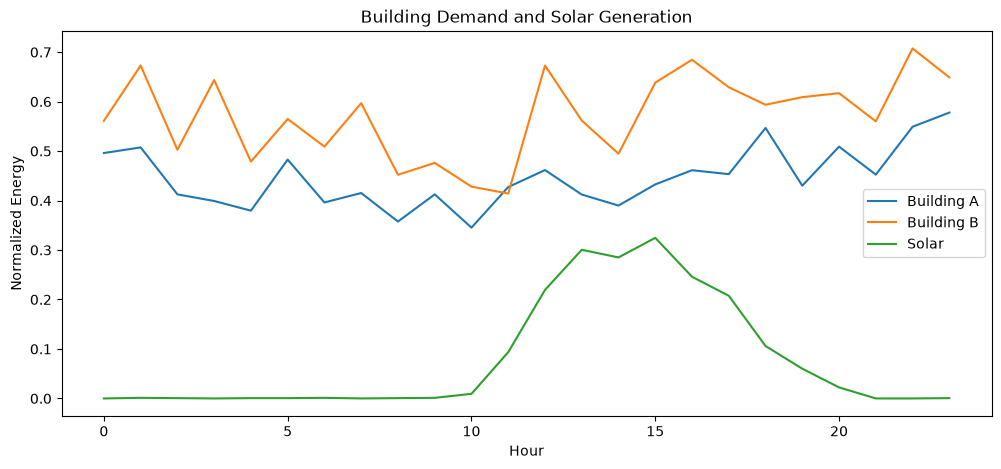

In [18]:
#Plotting energy behaviour

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history["step"], history["building_a_demand"], label="Building A")
ax.plot(history["step"], history["building_b_demand"], label="Building B")
ax.plot(history["step"], history["solar"], label="Solar")
ax.set_xlabel("Hour")
ax.set_ylabel("Normalized Energy")
ax.set_title("Building Demand and Solar Generation")
ax.legend()
plt.show()


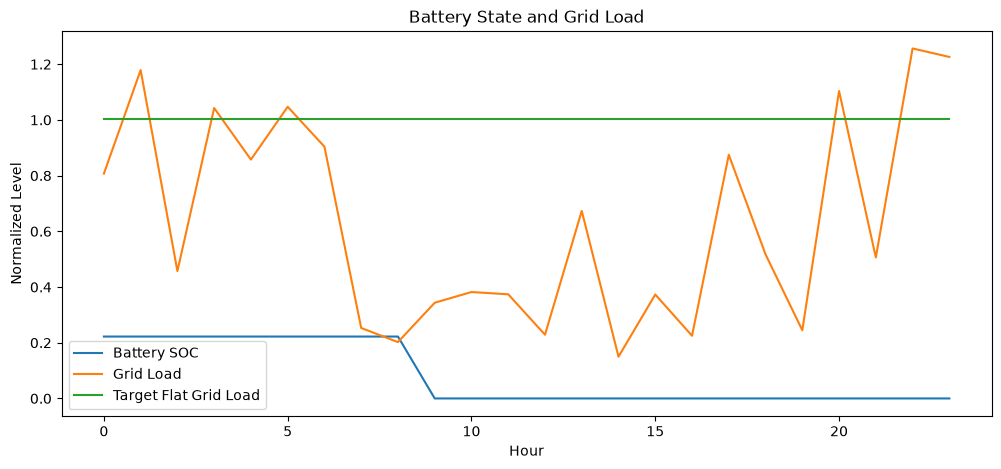

In [19]:
#Plotting battery and grid

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history["step"], history["battery_soc"], label="Battery SOC")
ax.plot(history["step"], history["grid_load"], label="Grid Load")
ax.plot(history["step"], history["target_grid_load"], label="Target Flat Grid Load")
ax.set_xlabel("Hour")
ax.set_ylabel("Normalized Level")
ax.set_title("Battery State and Grid Load")
ax.legend()
plt.show()

In [20]:
#Verifying energy balance

balance_error = (
    history["solar"]
    + history["battery_discharge"]
    + history["grid_import"]
    - history["total_demand"]
    - history["battery_charge"]
    - history["grid_export"]
)

print("Maximum energy balance error:", abs(balance_error).max())

Maximum energy balance error: 0.7590345836594369


Calculating final grid stability metric (GSI):

Compute the peak-to-average ratio of grid load: GSI = max(G_t) / mean(G_t)

In [21]:
#Final grid stability metric (GSI)

def calculate_gsi(grid_load):
    mean_load=np.mean(grid_load)
    if mean_load==0:
        return 1.0
    return np.max(grid_load)/mean_load

gsi=calculate_gsi(history["grid_load"].values)
print("Grid Stability Index:", gsi)

Grid Stability Index: 1.9803061623032203
